# Motif Finding
### Motif Finding na resposta ao stress em *Saccharomyces cerevisiae*

Licenciatura em Bioinformática | FCUP | 2025/26  
Afonso Santos, Joana Borges, Rafael Santos

---
**Estrutura do Notebook:**
1. **Contexto e Motivação:** Motifs, regulação transcricional e resposta ao stress da *S. cerevisiae*
2. **Método e Ferramenta:** O algoritmo MEME para a descoberta de motifs
3. **Hands-on Activity:** Pipeline prático
4. **Discussão e Conclusão** dos resultados obtidos
5. **Referências** bibliográficas
---

## 1. Contexto e Motivação

### Motifs e o seu contexto na Bioinformática
Na Bioinformática, motifs são padrões sequenciais conservados em DNA, RNA ou proteínas que possuem uma função biológica específica. A sua identificação é crucial para desvendar mecanismos regulatórios, prever sítios de ligação de fatores de transcrição e compreender a arquitetura funcional dos genomas. Estes padrões, muitas vezes curtos e degenerados, são a chave para decifrar como as células interpretam e respondem a sinais internos e externos.

### Motifs Regulatórios
Dentro da vasta categoria de motifs, os motifs regulatórios desempenham um papel crucial na orquestração da expressão génica. Estes são sequências específicas de DNA localizadas em regiões promotoras ou intensificadoras, que servem como sítios de ligação para fatores de transcrição. A interação entre os fatores de transcrição e os seus motifs regulatórios permite que as células ativem ou reprimam a expressão de genes de forma coordenada, em resposta a sinais internos ou ambientais. Este mecanismo é fundamental para a adaptação celular e para a manutenção da homeostasia.

### *Saccharomyces cerevisiae*
A levedura *Saccharomyces cerevisiae* é um organismo modelo unicelular que enfrenta flutuações constantes no seu ambiente. Para sobreviver, a célula precisa de ativar centenas de genes de proteção instantaneamente. 

Em 2000, Gasch et al. publicaram um estudo, "Genomic expression programs in the response of yeast cells to environmental changes", onde mostraram que a levedura possui um programa transcricional comum chamado **Environmental Stress Response (ESR)**, que envolve a regulação coordenada de cerca de 900 genes em resposta a quase qualquer tipo de stress, desde choque térmico a stress oxidativo.

Deste modo, a resposta ao stress reside nos **Motifs Regulatórios**, que são sequências curtas de DNA (geralmente com 5-15 bp) localizadas nas regiões promotoras dos genes. Fatores de Transcrição (TFs) reconhecem e ligam-se a estes motifs, recrutando a maquinaria de transcrição e ativando ou reprimindo a expressão génica.

### Respostas ao Stress em Leveduras
Dois dos fatores de transcrição mais importantes na ESR de *S. cerevisiae* são:
1. **HSF1 (Heat Shock Factor 1):** O principal regulador da resposta ao Heat Shock Response (HSR). Liga-se ao **HSE** (Heat Shock Element), um motif caracterizado por repetições do pentâmero `nGAAn`.
2. **MSN2/4:** Fatores de transcrição de dedos de zinco que orquestram a resposta geral ao stress. Ligam-se ao **STRE** (Stress Response Element), com a sequência consenso `AGGGG`.


| Motif Regulatório | Fator de Transcrição | Sequência Consenso | Resposta Associada | Função |
| :---------------- | :------------------- | :----------------- | :----------------- | :----- |
| **STRE**          | Msn2p / Msn4p        | 5’-AGGGG-3’        | ESR Geral          | Adaptação a múltiplos stresses |
| **HSE**           | HSF1                 | nGAAn (repetições) | HSR Específica     | Proteção contra danos proteicos (HSPs) |


---
## 2. Método e Ferramenta: O Algoritmo MEME

### MEME — Multiple Em for Motif Elicitation
O MEME é um dos algoritmos principais para a descoberta de motifs, que se foca em encontrar padrões recorrentes em sequências não alinhadas utilizando o algoritmo **Expectation-Maximization (EM)**, um método iterativo que leva a uma solução ótima local.

**Expectation-Maximization**
O algoritmo alterna entre dois passos principais até que o motif não mude significativamente:
1.  **E-step (Expectation):** O algoritmo estima em que posição o motif poderá estar em cada sequência.
2.  **M-step (Maximization):** O algoritmo utiliza as ocorrências mais prováveis estimadas no E-step com a finalidade de maximizar a verosimilhança do motif, tornando-o a melhor representação encontrada.

### Modelos de distribuição de ocorrências

A escolha do modelo de distribuição é crucial e depende da nossa hipótese sobre a ocorrência do motif nas sequências:

| Modelo | Descrição | Uso |
| :--- | :--- | :--- |
| **OOPS** | One Occurrence Per Sequence | Assume que o motif ocorre exatamente uma vez em *cada* sequência. Útil para datasets muito homogéneos. |
| **ZOOPS** | Zero or One Occurrence Per Sequence | Assume que o motif ocorre zero ou uma vez em *cada* sequência. Mais realista para a maioria dos datasets biológicos, onde nem todos os promotores contêm o motif. |
| **ANR** | Any Number of Repetitions | Assume que o motif pode ocorrer várias vezes em *qualquer* sequência. Ideal para motifs que se repetem (como o HSE do HSF1). |

### Significância: o E-value
O MEME reporta a significância dos motifs descobertos através do **E-value**. Este valor representa o número esperado de motifs com uma pontuação igual ou superior que seriam encontrados num conjunto de sequências aleatórias do mesmo tamanho e composição. Um E-value baixo (por exemplo, < 0.05) indica que o motif é estatisticamente significativo e provavelmente não é uma ocorrência aleatório.

---
## 3. Hands-On


### Setup | Imports Necessários

In [ ]:
%matplotlib inline
import time
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from Bio import Entrez, SeqIO, motifs

print("Os imports foram realizados com sucesso!")

O objetivo do Hands-On é responder à quetsão-problema “Como é que o Motif Finding nos permite inferir sobre a resposta ao stress em *S. cerevisiae*?”, através de uma pipeline que inclui:
1. **Extração** das sequências promotoras dos genes de interesse via NCBI
2. **Pesquisa manual** de motifs conhecidos (abordagem determinística)
3. **Descoberta automática** de motifs com o algoritmo MEME (abordagem probabilística)
4. **Análise e visualização** do output com BioPython
5. **Validação biológica** cruzando os motifs com dados de expressão génica
### Passo 1 — Preparação e carregamento dos dados e ficheiros *.fasta*

O promotor de um gene é a região de DNA imediatamente a montante (*upstream*) do codão de iniciação da transcrição. É aqui que os fatores de transcrição se ligam para ativar ou reprimir a expressão do gene.


Utilizamos sequências promotoras (500 bp a montante do codão de iniciação) de genes alvo de **HSF1** e **MSN2/4** em *S. cerevisiae*, obtidas directamente do NCBI.

Substitui o campo `Entrez.email` pelo teu endereço de e-mail e executa a célula para descarregar os 6 promotores e guardá-los no ficheiro `promoters.fasta`.

In [ ]:
Entrez.email = "____"  # <- coloca o teu email aqui

# gene: (cromossoma RefSeq, posição início CDS, strand, TF regulador)
genes = {
    "HSP104": ("NC_001144.5", 88624,  "+", "HSF1"),
    "SSA1":   ("NC_001133.9", 139504, "-", "HSF1"),
    "HSP26":  ("NC_001134.8", 382031, "+", "MSN2/4"),
    "CTT1":   ("NC_001139.9", 654635, "+", "MSN2/4"),
    "HSP12":  ("NC_001147.6", 231571, "-", "MSN2/4"),
    "DDR2":   ("NC_001138.5", 107257, "+", "MSN2/4"),
}

records = []
for gene, (chrom, cds_start, strand, tf) in genes.items():
    try:
        s, e, st = (max(1, cds_start - 500), cds_start - 1, 1) if strand == "+" \
                   else (cds_start + 1, cds_start + 500, 2)
        handle = Entrez.efetch(db="nuccore", id=chrom, rettype="fasta",
                               retmode="text", seq_start=s, seq_stop=e, strand=st)
        rec = list(SeqIO.parse(handle, "fasta"))[0]; handle.close()
        rec.id = rec.name = gene
        rec.description = f"{gene} | 500bp upstream | {tf}"
        records.append(rec)
        print(f"  {gene:8s} | {len(rec.seq)} bp | {tf}")
        time.sleep(0.4)
    except Exception as err:
        print(f"  {gene}: erro - {err}")

SeqIO.write(records, "promoters.fasta", "fasta")
print(f"\n{len(records)} promotores guardados em promoters.fasta")

### Passo 2 — Procura Manual de Motifs

Abordagem Determinística.

Antes de usar ferramentas automatizadas, vamos verificar manualmente se os motifs conhecidos estão presentes nos promotores.

**Recorda:** Como o DNA é de dupla cadeia, é necessário pesquisar tanto a sequência direta como o seu complemento reverso, pois a mesma informação pode estar na cadeia oposta.
- O **STRE** (alvo de MSN2/4) tem o consenso `_______` (e o complemento reverso `_______`).
- O **HSE** (alvo de HSF1) tem o consenso `_______` (e o complemento reverso `_______`).

**Exercicio:** Completa o codigo abaixo com os motifs correctos e os seus complementos reversos.
De seguida, completa o script Python que conta quantas vezes as strings exatas AGGGG (STRE) e GAA (HSE) aparecem nos promotores de 6 genes de stress.

Dica: o complemento reverso de uma sequência de DNA inverte a ordem e substitui cada base pela sua complementar (A<->T, C<->G).

In [ ]:
records = list(SeqIO.parse("promoters.fasta", "fasta"))

motifs_to_search = {
    "STRE (MSN2/4)": ["", ""],  # completa com as sequências consenso e complemento direto
    "HSE (HSF1)":    ["",   ""],
}

for motif_name, patterns in motifs_to_search.items():
    print(f"-> {motif_name}")
    for rec in records: 
        seq = str(rec.seq).upper()
        count = sum(seq.count(p) for p in patterns)
        print(f"{rec.id:8s} ({count}x)")
    print()

-> STRE (MSN2/4)
HSP104   (3x)
SSA1     (0x)
HSP26    (3x)
CTT1     (3x)
HSP12    (3x)
DDR2     (5x)

-> HSE (HSF1)
HSP104   (29x)
SSA1     (32x)
HSP26    (17x)
CTT1     (19x)
HSP12    (21x)
DDR2     (23x)



> **Questão:** O motif do HSF1 (`GAA`) apareceu dezenas de vezes, enquanto o STRE (`AGGGG`) apareceu muito menos. Será que todos estes "GAA" são locais reais de ligação do fator de transcrição? Quais são as limitações de confiar apenas numa contagem manual de strings tão curtas?

### Passo 3 — Descoberta de Motifs com MEME (Web Server)

Abordagem Probabilística.

Procurar motifs à mão só funciona se já soubermos o que estamos a procurar. Num cenário de investigação real, é necessário encontrar ocorrências repetidas de determinados padrões.

**Instruções:**
1. Acede ao [MEME Suite Web Server](https://meme-suite.org/meme/tools/meme)
2. Faz upload do ficheiro `promoters.fasta`
3. Configura os parâmetros:
   - **Distribuição:** Any Number of Repititions (ANR)
   - **Número de motifs:** 3
   - **Largura mínima:** 8 bp
   - **Largura máxima:** 12 bp 
4. Clica em **Start Search**
5. Descarrega o ficheiro `meme.xml` para a pasta de trabalho, vai ser usado no próximo passo


> **Questão:** Qual é o **E-value** do melhor motif?

### Passo 4

### Passo 4.1 — Ler o Output do MEME com BioPython
Para automatizar pipelines bioinformáticos, podemos ler os outputs do MEME diretamente no Python usando o módulo `motifs` do BioPython.

**Exercício:** Completa o código abaixo para: carregar o ficheiro meme.xml com o parser correto; classificar cada motif como estatisticamente significativo ou não, com base no limite convencional do E-value; e imprimir um resumo formatado de cada motif com o seu consenso, E-value, largura e número de ocorrências nos promotores. No final, deverás obter uma tabela textual que te permita comparar os três motifs descobertos e decidir quais merecem análise mais aprofundada.

In [ ]:
with open("meme.xml") as f:
    meme_record = motifs.parse(f, "meme")

print(f"Motifs encontrados: {len(meme_record)}\n")

for i, motif in enumerate(meme_record):
    sig = "significativo" if ___ else "não significativo" # completa
    print(f"  Motif {i+1}  [{sig}]")
    print(f"    Consenso    : {motif.consensus}")
    print(f"    E-value     : {}")  # completa de forma a imprimir o e-value com 2 casas decimais
    print(f"    Largura     : {} bp")  # completa com a largura do motif
    print(f"    Ocorrencias : {}")  # completa com o número de ocorrências nos promotores
    print()

> **Questão:** Olhem para o motif 2 ou 3. Conseguem encontrar as sequências AGGGG ou GAA dentro desses consensos mais longos? O que é que isto nos diz sobre a sensibilidade do MEME em comparação com a nossa contagem manual do Passo 1?"

### Passo 4.2 — Visualizar os Sequence Logos

Um sequence logo representa a conservação de cada posição do motif. A altura de cada letra é proporcional ao conteúdo de informação (bits) nessa posição e quanto mais alta, mais conservada.

O código abaixo gera os sequence logos para todos os motifs encontrados pelo MEME. Executa-o e interpreta os padrões de conservação.

In [ ]:
NUC_COLORS = {"A":"#27AE60","C":"#2980B9","G":"#F39C12","T":"#E74C3C"}
NUCS = ["A","C","G","T"]

def plot_logo(motif, ax):
    pfm = [[motif.pwm[n][i] for n in NUCS] for i in range(motif.length)]
    for pos, freq in enumerate(np.array(pfm)+1e-9):
        freq /= freq.sum()
        ic = max(0.0, 2.0-(-np.sum(freq*np.log2(freq))))
        bottom = 0.0
        for idx in np.argsort(freq):
            h = freq[idx]*ic
            ax.bar(pos+0.5, h, bottom=bottom, color=NUC_COLORS[NUCS[idx]], width=0.85)
            if h > 0.1:
                ax.text(pos+0.5, bottom+h/2, NUCS[idx], ha="center", va="center",
                        fontsize=max(6,int(h*6)), fontweight="bold", color="white")
            bottom += h
    ax.set(xlim=(0,motif.length), ylim=(0,2.1),
           xticks=np.arange(motif.length)+0.5, xticklabels=range(1,motif.length+1),
           ylabel="Bits", facecolor="#F8FAFC",
           title=f"{motif.consensus}  |  E={motif.evalue:.1e}  |  {motif.num_occurrences}x")
    ax.legend(handles=[mpatches.Patch(color=c,label=n) for n,c in NUC_COLORS.items()],
              loc="upper right", fontsize=7, ncol=4)

fig, axes = plt.subplots(len(meme_record), 1, figsize=(13, 3.5*len(meme_record)), squeeze=False)
for i, m in enumerate(meme_record):
    plot_logo(m, axes[i,0])
plt.suptitle("Sequence Logos — Motifs Descobertos pelo MEME\n(S. cerevisiae | Genes de Resposta ao Stress)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("motifs_logos.png", dpi=300, bbox_inches="tight")
plt.show()

> **Questão:** Quais as posições mais informativas de cada motif?

### Passo 5 — Resposta Biológica

Para verificar se os motifs identificados pelo algoritmo possuem relevância fisiológica real, cruzamos os motifs regulatórios das regiões promotoras com os perfis de expressão génica sob diferentes condições ambientais (baseado em "Genomic expression programs in the response of yeast cells to environmental changes.", Gasch, A. P. et al. (2000)).

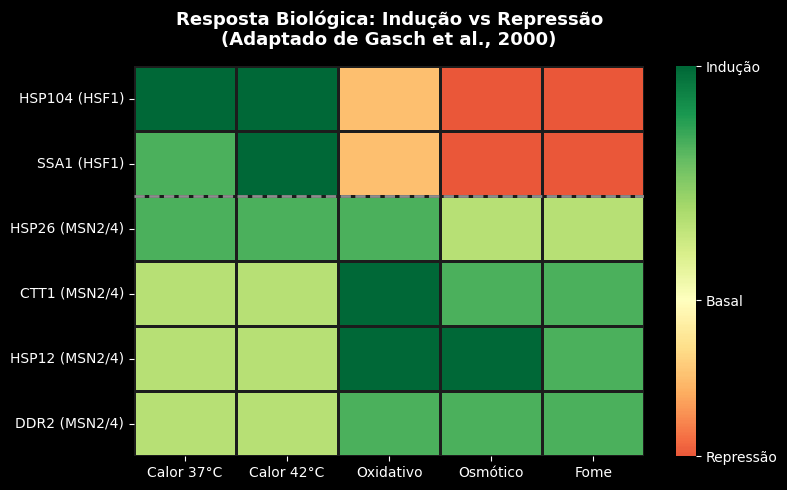

In [31]:
# Dados: Usamos valores negativos para Repressão e positivos para Indução
rna_data = pd.DataFrame(
    [[3, 3, -1, -2, -2],  # HSP104 
     [2, 3, -1, -2, -2],  # SSA1
     [2, 2, 2, 1, 1],     # HSP26
     [1, 1, 3, 2, 2],     # CTT1
     [1, 1, 3, 3, 2],     # HSP12
     [1, 1, 2, 2, 2]],    # DDR2
    index=["HSP104 (HSF1)", "SSA1 (HSF1)", "HSP26 (MSN2/4)", "CTT1 (MSN2/4)", "HSP12 (MSN2/4)", "DDR2 (MSN2/4)"],
    columns=["Calor 37°C", "Calor 42°C", "Oxidativo", "Osmótico", "Fome"]
)

# Setup visual 
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(8, 5))

# Vermelho para repressão (<0), Amarelo/Preto para neutro (0), Verde para indução (>0)
heatmap_rna = sns.heatmap(rna_data, annot=False, cmap="RdYlGn", center=0, ax=ax, 
                          linewidths=1, linecolor="#1c1c1c")

ax.set_title("Resposta Biológica: Indução vs Repressão\n(Adaptado de Gasch et al., 2000)", 
             fontweight="bold", pad=15, fontsize=13)

# Legenda
colorbar = heatmap_rna.collections[0].colorbar
colorbar.set_ticks([-2, 0, 3])
colorbar.set_ticklabels(['Repressão', 'Basal', 'Indução'])

# Linha divisória entre HSF1 e MSN2/4
ax.axhline(2, color="white", linewidth=2, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("resposta_biológica.png", dpi=300, transparent=True, bbox_inches='tight')
plt.show()

A análise do heatmap gerado demonstra a perfeita correspondência entre o código genómico e o comportamento celular: os genes **HSP104** e **SSA1**, que possuem principalmente o motif **HSE** reconhecido pelo fator de transcrição **HSF1**, revelam uma forte indução focada e especializada sob choque térmico (Calor 37°C e Calor 42°C), sendo ativamente reprimidos nas restantes condições ambientais (Oxidativo, Osmótico e Fome). 

Em contrapartida, os genes **HSP26**, **CTT1**, **HSP12** e **DDR2**, regulados pelo fator **Msn2p/Msn4p** através do motif **STRE** (*HSP26*, *CTT1*, *HSP12* e *DDR2*) apresentam o perfil dinâmico da resposta geral ao stress (ESR); embora sejam também induzidos durante o choque térmico, a sua ativação e níveis de expressão são substancialmente mais robustos e melhor induzidos sob condições de stress oxidativo, osmótico e fome, validando a especificidade funcional de cada interruptor molecular deduzido computacionalmente.

---
## 4. Discussão e Conclusão

Este trabalho permitiu-nos explorar o pipeline completo de descoberta de motifs regulatórios, evidenciando as limitações e avanços da Bioinformática:

**Descoberta de Motifs (Abordagem Probabilística):** A procura manual (determinística) mostrou-se ineficiente tendo em conta variabilidade biológica dos motifs. Por outro lado, a abordagem probabilística do algoritmo MEME revelou ser a ferramenta correta para detetar padrões conservados, demonstrando que a eficácia depende da parametrização correta (E-values e modelos de distribuição) para separar o sinal real do ruído genómico.

**Validação Funcional:** A identificação de uma sequência repetida no DNA é apenas um exercício estatístico até ser validada. Ao cruzar os nossos motifs descobertos (como HSE e STRE) com os dados de transcriptómica (RNA) de *Gasch et al. (2000)*, confirmámos que estes elementos são, de facto, os interruptores moleculares que coordenam a resposta ao stress (ESR).  

**Resposta Biológica:** O pipeline validou que a *S. cerevisiae* possui duas lógicas de sobrevivência distintas: o modo específico do HSF1 (alvo do motif HSE), que responde apenas a choque térmico, e o modo geral do MSN2/4 (alvo do motif STRE), que apresenta resposta contra múltiplas condições de stress.  

**Síntese Final:**
Este trabalho confirmou que os motifs regulatórios dos promotores são determinantes na resposta fisiológica ao stress da *S. cerevisiae*. Ao descobrir o motif no DNA, conseguimos prever com precisão a resposta transcricional. 



---
## 5. Referências

1. Gasch, A. P. et al. (2000). Genomic expression programs in the response of yeast cells to environmental changes. *Molecular Biology of the Cell*.
2. Schmitt, A. P., & McEntee, K. (1996). Msn2p, a zinc finger DNA-binding protein, is a component of the general stress response machinery in *S. cerevisiae*. *PNAS*.
3. Bailey, T. L., & Elkan, C. (1994). Fitting a mixture model by expectation maximization to discover motifs in biopolymers. *ISMB*.
4. Bailey, T. L. et al. (2015). The MEME Suite. *Nucleic Acids Research*.
5. *Apontamentos e material de apoio da UC de Algoritmos para a Análise de Sequências Biológicas* [Moodle]. FCUP, 2025/26.